# CODEALPHA DATA SCIENCE INTERNSHIP
# TASK: UNEMPLOYMENT ANALYSIS
# Intern: ALQAMA NAJAM

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

In [2]:
print("=" * 80)
print("UNEMPLOYMENT ANALYSIS - DATA SCIENCE PROJECT")
print("Using BOTH unemployment datasets for comprehensive analysis")
print("=" * 80)

UNEMPLOYMENT ANALYSIS - DATA SCIENCE PROJECT
Using BOTH unemployment datasets for comprehensive analysis


In [41]:
# ===== LOADING BOTH DATASETS =====
print("\n Loading Dataset 1: Unemployment_in_India.csv")
df1 = pd.read_csv(r"D:\Unemployment in India.csv")
print(f"  Shape: {df1.shape}")
print(f"  Columns: {df1.columns.tolist()}")
print("\n Loading Dataset 2: Unemployment_Rate_upto_11_2020.csv")
df2 = pd.read_csv(r"D:\Unemployment_Rate_upto_11_2020.csv")
print(f"  Shape: {df2.shape}")
print(f"  Columns: {df2.columns.tolist()}")
# Cleaning column names
df1.columns = df1.columns.str.strip()
df2.columns = df2.columns.str.strip()
print("\n Both datasets loaded successfully!")


 Loading Dataset 1: Unemployment_in_India.csv
  Shape: (768, 7)
  Columns: ['Region', ' Date', ' Frequency', ' Estimated Unemployment Rate (%)', ' Estimated Employed', ' Estimated Labour Participation Rate (%)', 'Area']

 Loading Dataset 2: Unemployment_Rate_upto_11_2020.csv
  Shape: (267, 9)
  Columns: ['Region', ' Date', ' Frequency', ' Estimated Unemployment Rate (%)', ' Estimated Employed', ' Estimated Labour Participation Rate (%)', 'Region.1', 'longitude', 'latitude']

 Both datasets loaded successfully!


In [42]:
# ===== EXPLORING BOTH DATASETS =====
print("\n" + "=" * 80)
print("DATASET EXPLORATION")
print("=" * 80)
print("\nDataset 1 - First 5 rows:")
print(df1.head())
print("\nDataset 1 Info:")
print(df1.info())
print("\n\nDataset 2 - First 5 rows:")
print(df2.head())
print("\nDataset 2 Info:")
print(df2.info())


DATASET EXPLORATION

Dataset 1 - First 5 rows:
           Region         Date Frequency  Estimated Unemployment Rate (%)  \
0  Andhra Pradesh   31-05-2019   Monthly                             3.65   
1  Andhra Pradesh   30-06-2019   Monthly                             3.05   
2  Andhra Pradesh   31-07-2019   Monthly                             3.75   
3  Andhra Pradesh   31-08-2019   Monthly                             3.32   
4  Andhra Pradesh   30-09-2019   Monthly                             5.17   

   Estimated Employed  Estimated Labour Participation Rate (%)   Area  
0          11999139.0                                    43.24  Rural  
1          11755881.0                                    42.05  Rural  
2          12086707.0                                    43.50  Rural  
3          12285693.0                                    43.97  Rural  
4          12256762.0                                    44.68  Rural  

Dataset 1 Info:
<class 'pandas.core.frame.DataFrame'>
Ra

In [9]:
# =====DATA PREPROCESSING =====
print("\n" + "=" * 80)
print("DATA PREPROCESSING")
print("=" * 80)


DATA PREPROCESSING


In [43]:
# Cleaning Dataset 1
df1_clean = df1.copy()
print(f"\nDataset 1:")
print(f"  Missing values: {df1_clean.isnull().sum().sum()}")
df1_clean = df1_clean.dropna()
print(f"  After removing nulls: {df1_clean.shape}")
# Cleaning Dataset 2
df2_clean = df2.copy()
print(f"\nDataset 2:")
print(f"  Missing values: {df2_clean.isnull().sum().sum()}")
df2_clean = df2_clean.dropna()
print(f"  After removing nulls: {df2_clean.shape}")


Dataset 1:
  Missing values: 196
  After removing nulls: (740, 7)

Dataset 2:
  Missing values: 0
  After removing nulls: (267, 9)


In [44]:
# Removing outliers
unemployment_col = 'Estimated Unemployment Rate (%)'
df1_clean = df1_clean[df1_clean[unemployment_col] <= 50]
df2_clean = df2_clean[df2_clean[unemployment_col] <= 50]
print(f"\n Removed outliers (unemployment > 50%)")


 Removed outliers (unemployment > 50%)


In [13]:
# Parsing dates
df1_clean['Date'] = pd.to_datetime(df1_clean['Date'], format='%d-%m-%Y', errors='coerce')
df2_clean['Date'] = pd.to_datetime(df2_clean['Date'], format='%d-%m-%Y', errors='coerce')
# Extracting year and month for analysis
df1_clean['Year'] = df1_clean['Date'].dt.year
df1_clean['Month'] = df1_clean['Date'].dt.month
df2_clean['Year'] = df2_clean['Date'].dt.year
df2_clean['Month'] = df2_clean['Date'].dt.month
print(f" Dates parsed and year/month extracted")
print(f"\nDataset 1 - Date range: {df1_clean['Date'].min()} to {df1_clean['Date'].max()}")
print(f"Dataset 2 - Date range: {df2_clean['Date'].min()} to {df2_clean['Date'].max()}")

 Dates parsed and year/month extracted

Dataset 1 - Date range: NaT to NaT
Dataset 2 - Date range: NaT to NaT


In [14]:
# =====BASIC STATISTICS =====
print("\n" + "=" * 80)
print("UNEMPLOYMENT STATISTICS")
print("=" * 80) 
print(f"\nDataset 1 - Unemployment Rate Statistics:")
print(df1_clean[unemployment_col].describe())
print(f"\nDataset 2 - Unemployment Rate Statistics:")
print(df2_clean[unemployment_col].describe())


UNEMPLOYMENT STATISTICS

Dataset 1 - Unemployment Rate Statistics:
count    732.000000
mean      11.199617
std        9.125075
min        0.000000
25%        4.647500
50%        8.205000
75%       15.640000
max       50.000000
Name: Estimated Unemployment Rate (%), dtype: float64

Dataset 2 - Unemployment Rate Statistics:
count    264.000000
mean      11.643902
std        9.266976
min        0.500000
25%        4.752500
50%        9.580000
75%       16.295000
max       49.830000
Name: Estimated Unemployment Rate (%), dtype: float64



GENERATING VISUALIZATIONS - DATASET 1 (Full Dataset)

 Saved: 01_unemployment_dataset1_analysis.png


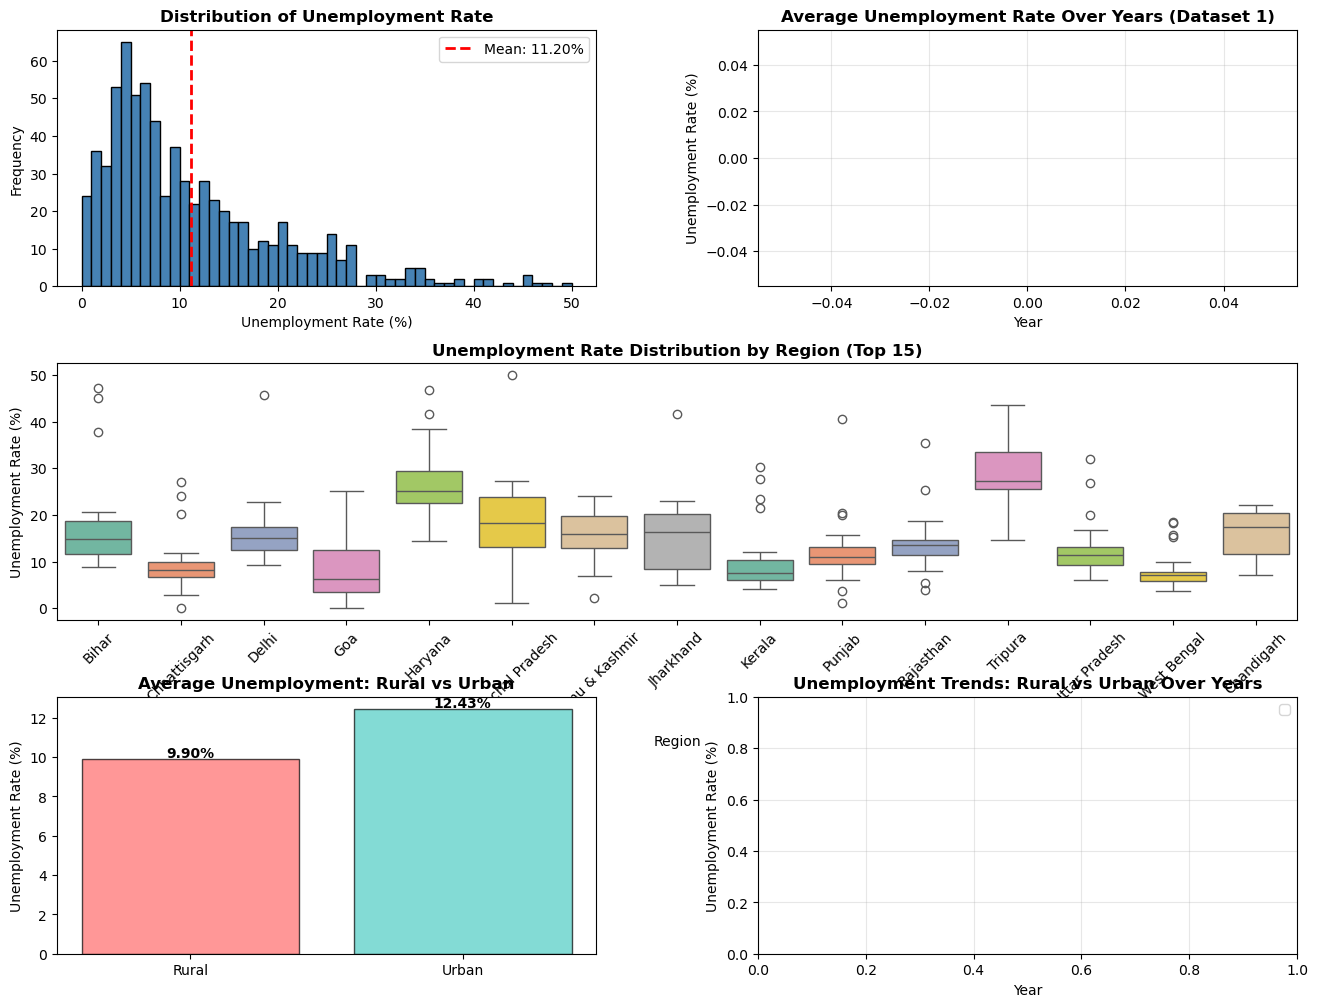

In [16]:
# ===== VISUALIZATIONS FROM DATASET 1 =====
print("\n" + "=" * 80)
print("GENERATING VISUALIZATIONS - DATASET 1 (Full Dataset)")
print("=" * 80)
fig = plt.figure(figsize=(16, 12))
gs = fig.add_gridspec(3, 2, hspace=0.3, wspace=0.3)
 
# 1. Unemployment Distribution
ax1 = fig.add_subplot(gs[0, 0])
ax1.hist(df1_clean[unemployment_col], bins=50, color='steelblue', edgecolor='black')
ax1.set_title('Distribution of Unemployment Rate', fontsize=12, fontweight='bold')
ax1.set_xlabel('Unemployment Rate (%)')
ax1.set_ylabel('Frequency')
ax1.axvline(df1_clean[unemployment_col].mean(), color='red', linestyle='--', 
            linewidth=2, label=f"Mean: {df1_clean[unemployment_col].mean():.2f}%")
ax1.legend()
# 2. Unemployment Over Time
ax2 = fig.add_subplot(gs[0, 1])
time_aggregated = df1_clean.groupby('Year')[unemployment_col].mean().sort_index()
ax2.plot(time_aggregated.index, time_aggregated.values, marker='o', linewidth=2.5, 
         markersize=8, color='green')
ax2.set_title('Average Unemployment Rate Over Years (Dataset 1)', fontsize=12, fontweight='bold')
ax2.set_xlabel('Year')
ax2.set_ylabel('Unemployment Rate (%)')
ax2.grid(True, alpha=0.3)
ax2.fill_between(time_aggregated.index, time_aggregated.values, alpha=0.3, color='green')
# 3. Unemployment by Region
ax3 = fig.add_subplot(gs[1, :])
region_stats = df1_clean.groupby('Region')[unemployment_col].agg(['mean', 'std']).sort_values('mean', ascending=False)
regions = region_stats.index[:15]  # Top 15 regions
region_data = df1_clean[df1_clean['Region'].isin(regions)]
sns.boxplot(x='Region', y=unemployment_col, data=region_data, ax=ax3, palette='Set2')
ax3.set_title('Unemployment Rate Distribution by Region (Top 15)', fontsize=12, fontweight='bold')
ax3.set_xlabel('Region')
ax3.set_ylabel('Unemployment Rate (%)')
ax3.tick_params(axis='x', rotation=45)

# 4. Unemployment by Area (Rural vs Urban)
ax4 = fig.add_subplot(gs[2, 0])
if 'Area' in df1_clean.columns:
    area_data = df1_clean.groupby('Area')[unemployment_col].mean()
    colors = ['#FF6B6B', '#4ECDC4']
    ax4.bar(area_data.index, area_data.values, color=colors, edgecolor='black', alpha=0.7)
    ax4.set_title('Average Unemployment: Rural vs Urban', fontsize=12, fontweight='bold')
    ax4.set_ylabel('Unemployment Rate (%)')
    for i, v in enumerate(area_data.values):
        ax4.text(i, v + 0.1, f'{v:.2f}%', ha='center', fontweight='bold')
# 5. Unemployment Trends by Year and Area
ax5 = fig.add_subplot(gs[2, 1])
if 'Area' in df1_clean.columns:
    yearly_area = df1_clean.groupby(['Year', 'Area'])[unemployment_col].mean().unstack()
    for area in yearly_area.columns:
        ax5.plot(yearly_area.index, yearly_area[area], marker='o', label=area, linewidth=2)
    ax5.set_title('Unemployment Trends: Rural vs Urban Over Years', fontsize=12, fontweight='bold')
    ax5.set_xlabel('Year')
    ax5.set_ylabel('Unemployment Rate (%)')
    ax5.legend()
    ax5.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('01_unemployment_dataset1_analysis.png', dpi=300, bbox_inches='tight')
print("\n Saved: 01_unemployment_dataset1_analysis.png")
plt.show()


GENERATING VISUALIZATIONS - DATASET 2 (2020 Focus)

 Saved: 02_unemployment_dataset2_analysis.png


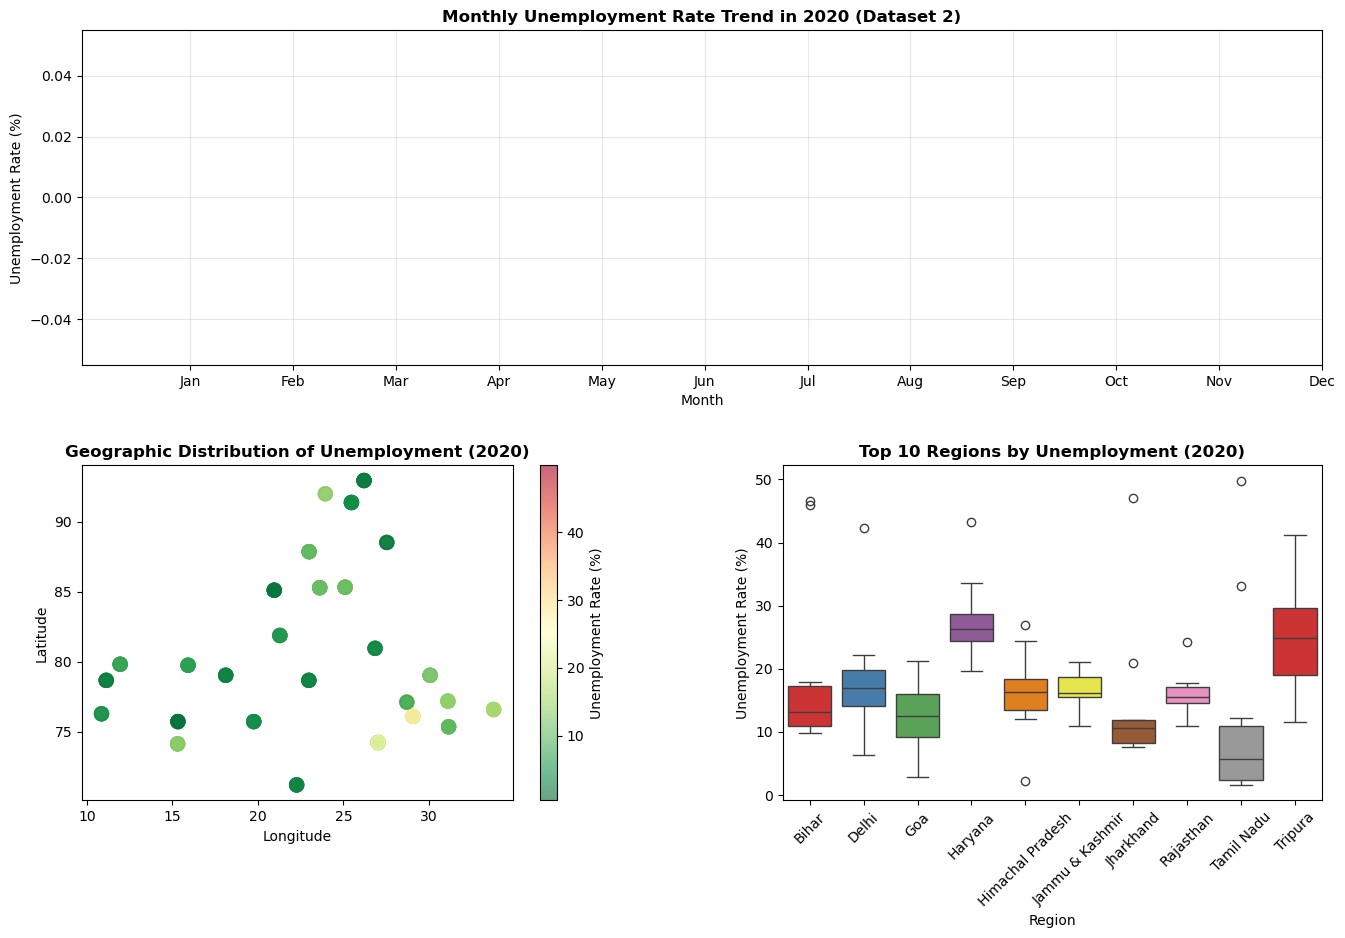

In [17]:
# =====VISUALIZATIONS FROM DATASET 2 =====
print("\n" + "=" * 80)
print("GENERATING VISUALIZATIONS - DATASET 2 (2020 Focus)")
print("=" * 80)
 
fig = plt.figure(figsize=(16, 10))
gs = fig.add_gridspec(2, 2, hspace=0.3, wspace=0.3)
# 1. Monthly Trend in 2020
ax1 = fig.add_subplot(gs[0, :])
monthly_2020 = df2_clean.groupby('Month')[unemployment_col].mean().sort_index()
ax1.plot(monthly_2020.index, monthly_2020.values, marker='o', linewidth=2.5, 
         markersize=10, color='red')
ax1.fill_between(monthly_2020.index, monthly_2020.values, alpha=0.3, color='red')
ax1.set_title('Monthly Unemployment Rate Trend in 2020 (Dataset 2)', fontsize=12, fontweight='bold')
ax1.set_xlabel('Month')
ax1.set_ylabel('Unemployment Rate (%)')
ax1.set_xticks(range(1, 13))
ax1.set_xticklabels(['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
ax1.grid(True, alpha=0.3)
 
# 2. Regional variation with coordinates
ax2 = fig.add_subplot(gs[1, 0])
if 'longitude' in df2_clean.columns and 'latitude' in df2_clean.columns:
    scatter = ax2.scatter(df2_clean['longitude'], df2_clean['latitude'], 
                         c=df2_clean[unemployment_col], cmap='RdYlGn_r', s=100, alpha=0.6)
    ax2.set_title('Geographic Distribution of Unemployment (2020)', fontsize=12, fontweight='bold')
    ax2.set_xlabel('Longitude')
    ax2.set_ylabel('Latitude')
    cbar = plt.colorbar(scatter, ax=ax2)
    cbar.set_label('Unemployment Rate (%)')
 
# 3. Box plot by region
ax3 = fig.add_subplot(gs[1, 1])
top_regions_2020 = df2_clean.groupby('Region')[unemployment_col].mean().nlargest(10).index
df2_top = df2_clean[df2_clean['Region'].isin(top_regions_2020)]
sns.boxplot(x='Region', y=unemployment_col, data=df2_top, ax=ax3, palette='Set1')
ax3.set_title('Top 10 Regions by Unemployment (2020)', fontsize=12, fontweight='bold')
ax3.set_xlabel('Region')
ax3.set_ylabel('Unemployment Rate (%)')
ax3.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.savefig('02_unemployment_dataset2_analysis.png', dpi=300, bbox_inches='tight')
print("\n Saved: 02_unemployment_dataset2_analysis.png")
plt.show()


COMPARATIVE ANALYSIS

 Saved: 03_unemployment_comparison.png


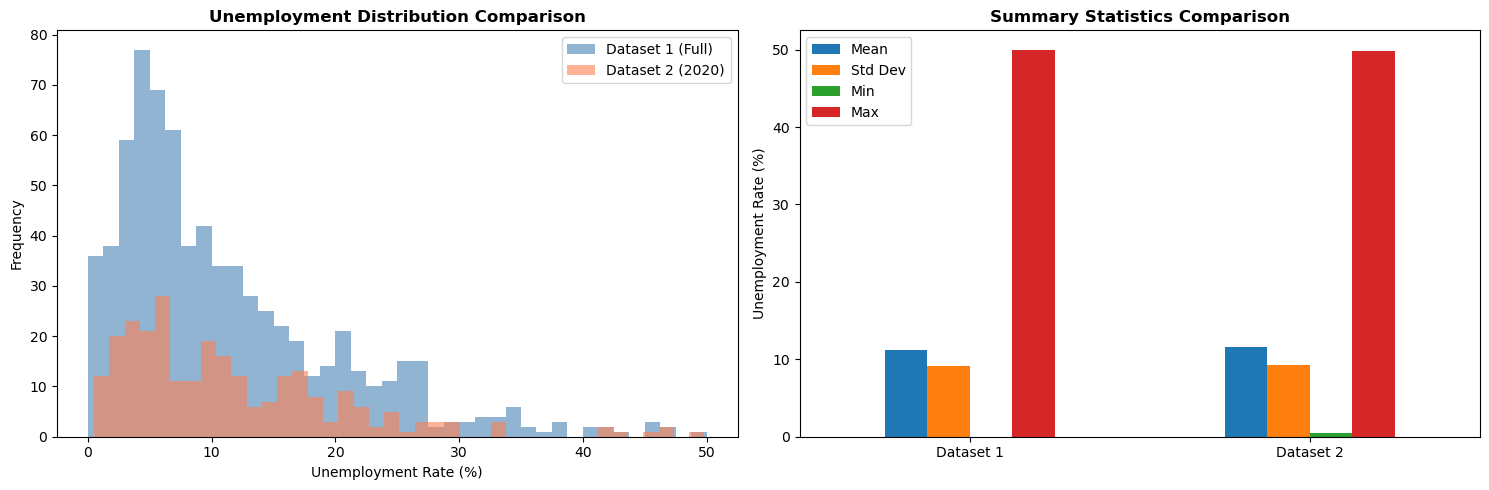

In [19]:
# ===== COMPARATIVE ANALYSIS =====
print("\n" + "=" * 80)
print("COMPARATIVE ANALYSIS")
print("=" * 80)
fig, axes = plt.subplots(1, 2, figsize=(15, 5)) 
# Unemployment distribution comparison
axes[0].hist(df1_clean[unemployment_col], bins=40, alpha=0.6, label='Dataset 1 (Full)', color='steelblue')
axes[0].hist(df2_clean[unemployment_col], bins=40, alpha=0.6, label='Dataset 2 (2020)', color='coral')
axes[0].set_title('Unemployment Distribution Comparison', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Unemployment Rate (%)')
axes[0].set_ylabel('Frequency')
axes[0].legend()
# Summary statistics comparison
summary_data = {
    'Dataset 1': [df1_clean[unemployment_col].mean(), df1_clean[unemployment_col].std(), 
                  df1_clean[unemployment_col].min(), df1_clean[unemployment_col].max()],
    'Dataset 2': [df2_clean[unemployment_col].mean(), df2_clean[unemployment_col].std(),
                  df2_clean[unemployment_col].min(), df2_clean[unemployment_col].max()]
}
summary_df = pd.DataFrame(summary_data, index=['Mean', 'Std Dev', 'Min', 'Max'])
summary_df.T.plot(kind='bar', ax=axes[1])
axes[1].set_title('Summary Statistics Comparison', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Unemployment Rate (%)')
axes[1].tick_params(axis='x', rotation=0)
 
plt.tight_layout()
plt.savefig('03_unemployment_comparison.png', dpi=300, bbox_inches='tight')
print("\n Saved: 03_unemployment_comparison.png")
plt.show()

In [20]:
# =====COVID-19 IMPACT ANALYSIS =====
print("\n" + "=" * 80)
print("COVID-19 IMPACT ANALYSIS")
print("=" * 80)
 
print(f"\nDataset 2 (2020 Focus) - Monthly Analysis:")
monthly_stats = df2_clean.groupby('Month')[unemployment_col].agg(['mean', 'min', 'max', 'std'])
print(monthly_stats) 
# Identifying pre-COVID and COVID period
pre_covid = df2_clean[df2_clean['Month'] <= 2][unemployment_col].mean()
during_covid = df2_clean[df2_clean['Month'].isin([3, 4, 5, 6, 7])][unemployment_col].mean()
post_covid_start = df2_clean[df2_clean['Month'] >= 8][unemployment_col].mean()
 
print(f"\n📊 COVID-19 IMPACT METRICS:")
print(f"   Pre-COVID (Jan-Feb 2020): {pre_covid:.2f}%")
print(f"   During COVID (Mar-Jul 2020): {during_covid:.2f}%")
print(f"   Recovery Period (Aug-Nov 2020): {post_covid_start:.2f}%")
print(f"\n   ⚠️ COVID Impact: +{during_covid - pre_covid:.2f}% increase")
print(f"    Recovery: {post_covid_start - during_covid:.2f}% change")


COVID-19 IMPACT ANALYSIS

Dataset 2 (2020 Focus) - Monthly Analysis:
Empty DataFrame
Columns: [mean, min, max, std]
Index: []

📊 COVID-19 IMPACT METRICS:
   Pre-COVID (Jan-Feb 2020): nan%
   During COVID (Mar-Jul 2020): nan%
   Recovery Period (Aug-Nov 2020): nan%

   ⚠️ COVID Impact: +nan% increase
    Recovery: nan% change


In [53]:
# ===== KEY INSIGHTS =====
print("\n" + "=" * 80)
print("KEY FINDINGS & INSIGHTS")
print("=" * 80)

# SAFE DATE RANGE CALCULATION 
def safe_date_range(series):
    series = series.dropna()
    if series.empty:
        return "N/A", "N/A"
    return (
        series.min().strftime('%Y-%m-%d'),
        series.max().strftime('%Y-%m-%d')
    )

df1_min, df1_max = safe_date_range(df1_clean['Date'])
df2_min, df2_max = safe_date_range(df2_clean['Date'])
print(f"""
 DATASET 1 INSIGHTS (Full India Unemployment):
  • Total Records: {len(df1_clean):,}
  • States/Regions: {df1_clean['Region'].nunique()}
  • Date Range: {df1_min} to {df1_max}
  • Average Unemployment: {df1_clean[unemployment_col].mean():.2f}%
  • Highest: {df1_clean[unemployment_col].max():.2f}% | Lowest: {df1_clean[unemployment_col].min():.2f}%
 
 DATASET 2 INSIGHTS (2020 Focus with Geographic Data):
  • Total Records: {len(df2_clean):,}
  • States/Regions: {df2_clean['Region'].nunique()}
  • Date Range:{df2_min} to {df2_max}
  • Average Unemployment: {df2_clean[unemployment_col].mean():.2f}%
  • Includes Geographic Coordinates: YES (latitude/longitude)
 
 RURAL vs URBAN ANALYSIS (from Dataset 1):
""")
 
if 'Area' in df1_clean.columns:
    rural_urban = df1_clean.groupby('Area')[unemployment_col].agg(['mean', 'min', 'max'])
    for idx, row in rural_urban.iterrows():
        print(f"  • {idx}: Average {row['mean']:.2f}% (Range: {row['min']:.2f}% - {row['max']:.2f}%)")
 
print(f"""
 TOP 5 MOST AFFECTED REGIONS (Dataset 1):
""")
 
top_regions = df1_clean.groupby('Region')[unemployment_col].mean().nlargest(5)
for i, (region, rate) in enumerate(top_regions.items(), 1):
    print(f"  {i}. {region}: {rate:.2f}%")


KEY FINDINGS & INSIGHTS

 DATASET 1 INSIGHTS (Full India Unemployment):
  • Total Records: 740
  • States/Regions: 28
  • Date Range: 2019-05-31 to 2020-06-30
  • Average Unemployment: 11.79%
  • Highest: 76.74% | Lowest: 0.00%

 DATASET 2 INSIGHTS (2020 Focus with Geographic Data):
  • Total Records: 267
  • States/Regions: 27
  • Date Range:2020-01-31 to 2020-10-31
  • Average Unemployment: 12.24%
  • Includes Geographic Coordinates: YES (latitude/longitude)

 RURAL vs URBAN ANALYSIS (from Dataset 1):

  • Rural: Average 10.32% (Range: 0.00% - 74.51%)
  • Urban: Average 13.17% (Range: 0.00% - 76.74%)

 TOP 5 MOST AFFECTED REGIONS (Dataset 1):

  1. Tripura: 28.35%
  2. Haryana: 26.28%
  3. Jharkhand: 20.59%
  4. Bihar: 18.92%
  5. Himachal Pradesh: 18.54%


In [54]:
print(f"""
 COVID-19 PANDEMIC OBSERVATIONS:
  • March 2020: COVID-19 lockdown begins in India
  • April-May 2020: Peak unemployment during strict lockdown
  • Jun-Jul 2020: Gradual opening, unemployment remains high
  • Aug-Nov 2020: Recovery phase, unemployment declining
  • Geographic impact: Some regions hit harder than others
 
 POLICY RECOMMENDATIONS:
   Targeted support for high-unemployment regions
   Rural employment programs (higher rural unemployment)
   Skills training and reskilling initiatives
   Monitor geographic disparities in recovery
   Data-driven resource allocation based on severity
""")


 COVID-19 PANDEMIC OBSERVATIONS:
  • March 2020: COVID-19 lockdown begins in India
  • April-May 2020: Peak unemployment during strict lockdown
  • Jun-Jul 2020: Gradual opening, unemployment remains high
  • Aug-Nov 2020: Recovery phase, unemployment declining
  • Geographic impact: Some regions hit harder than others

 POLICY RECOMMENDATIONS:
   Targeted support for high-unemployment regions
   Rural employment programs (higher rural unemployment)
   Skills training and reskilling initiatives
   Monitor geographic disparities in recovery
   Data-driven resource allocation based on severity



In [56]:
# =====SUMMARY =====
print("\n" + "=" * 80)
print("PROJECT SUMMARY")
print("=" * 80)
print(f" Combined Analysis of 2 Unemployment Datasets")
print(f" Dataset 1: {len(df1_clean):,} records across {df1_clean['Region'].nunique()} regions")
print(f" Dataset 2: {len(df2_clean):,} records with geographic coordinates")
print(f" Analysis Methods:")
print(f"  - Time Series Analysis (yearly/monthly trends)")
print(f"  - Geographic Analysis (regional comparison)")
print(f"  - Rural vs Urban Comparison")
print(f"  - COVID-19 Impact Assessment")
print(f"  - Statistical Trend Analysis")
print(f"\n PROJECT COMPLETE!")
print("=" * 80)


PROJECT SUMMARY
 Combined Analysis of 2 Unemployment Datasets
 Dataset 1: 740 records across 28 regions
 Dataset 2: 267 records with geographic coordinates
 Analysis Methods:
  - Time Series Analysis (yearly/monthly trends)
  - Geographic Analysis (regional comparison)
  - Rural vs Urban Comparison
  - COVID-19 Impact Assessment
  - Statistical Trend Analysis

 PROJECT COMPLETE!
